# NeRF Reconstruction with Custom Adam

**Project title:** Optimization for 3D Scene Reconstruction: A Comparative Study of Optimizers, Losses, and Representations for NeRF and 3D Gaussian Splatting

**Group:** António Cruz, Duarte Cabrita

**Submission date:** May 18, 2026

---

# Problem Formulation

## The task

3D scene reconstruction from a sparse set of 2D photographs, framed as a continuous non-convex optimization problem.

## Mathematical formulation

Let $\theta$ be the parameters (weights and biases) of a small multi-layer perceptron $f_\theta$ that maps a 3D point $(x, y, z)$ to a density $\sigma \ge 0$ and an RGB colour $c \in [0, 1]^3$.

Let $R(\theta; \pi)$ be the differentiable volume-rendering operator: given $\theta$ and a camera pose $\pi$, it casts rays through every pixel, samples points along each ray, queries $f_\theta$, and composites the samples into a synthesised image.

Given captured images and their camera poses $\{(I_i, \pi_i)\}_{i=1..N}$, we minimise the average squared discrepancy:

$$\min_\theta \ \ \frac{1}{N}\sum_{i=1}^{N} \| R(\theta; \pi_i) - I_i \|_2^2$$

The problem is non-convex (the rendering operator composes with the MLP non-linearities) and high-dimensional ($|\theta|$ on the order of $10^5$ parameters even for the tiny model). It is solved by stochastic gradient methods.

## Method (this PoC)

Stochastic mini-batch optimization with a custom Adam optimizer implemented from scratch on top of PyTorch's automatic differentiation. At each iteration we sample a random training image, sample a random batch of pixel rays from it, render those pixels, compute the L2 loss against the ground truth, and update $\theta$ using Adam's bias-corrected first- and second-moment estimates.

## Why this PoC exists

Before scaling to the full project (multiple custom optimizers, multiple loss formulations, multiple scenes, plus a 3D Gaussian Splatting baseline), we verify that the end-to-end pipeline (custom Adam, custom volume renderer, small MLP) converges and produces a 3D representation that supports novel-view synthesis. The success criterion is qualitative (rendered novel views are recognisable) and quantitative (held-out PSNR clearly above 20 dB).

---


# 1. Environment Setup

Import libraries, set global hyperparameters, and fix random seeds for reproducibility. All training and rendering runs on the GPU (`DEVICE = "cuda"`). The seed setting ensures the loss curve and the final PSNR/SSIM numbers are reproducible across runs of the notebook.

In [1]:
# Libraries import

import math
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from skimage.metrics import structural_similarity as ssim_metric


In [2]:
# Global variables

DEVICE = "cuda"
DATASET_PATH = "../data/tiny_nerf_data.npz"
RES = 100             # native resolution of tiny_nerf_data
N_SAMPLES = 64        # samples per ray
BATCH_RAYS = 1024
N_ITERATIONS = 5000
LR = 5e-4

# Reproducibility: fix all random sources so runs are repeatable across sessions.
SEED = 0
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)


In [3]:
d = np.load(DATASET_PATH)

print({k: d[k].shape for k in d.files})

{'images': (106, 100, 100, 3), 'poses': (106, 4, 4), 'focal': ()}


# 2. Data Loading

Load the Tiny NeRF preprocessed dataset (`tiny_nerf_data.npz`): 106 rendered images of the Lego scene at 100x100 with their camera-to-world poses and the shared focal length. The last image is held out as the test view (used only for evaluation); the remaining 105 are training views.

In [4]:
data = np.load(DATASET_PATH)
images = torch.tensor(data["images"], dtype=torch.float32, device=DEVICE)   # [N, 100, 100, 3]
poses  = torch.tensor(data["poses"],  dtype=torch.float32, device=DEVICE)   # [N, 4, 4]
focal  = float(data["focal"])

# Hold out the last image as a test view; train on the rest.
train_images, train_poses = images[:-1], poses[:-1]
test_image,   test_pose   = images[-1],  poses[-1]

H, W = train_images.shape[1], train_images.shape[2]
print(f"Loaded {len(train_images)} training images at {H}x{W}, focal={focal:.2f}")

Loaded 105 training images at 100x100, focal=138.89


# 3. Ray Generation

For a given image resolution and camera pose, generate a ray (origin + direction in world coordinates) for every pixel. These rays are the inputs to the volume-rendering integral. The rendering operator $R(\theta;\pi)$ in the formulation is realised by this function plus the volume renderer in Section 6.

In [5]:
def get_rays(H, W, focal, pose):
    """Return ray origins and directions for every pixel in an HxW image."""
    i, j = torch.meshgrid(
        torch.arange(W, device=DEVICE).float(),
        torch.arange(H, device=DEVICE).float(),
        indexing="xy",
    )
    dirs = torch.stack([(i - W * 0.5) / focal, -(j - H * 0.5) / focal, -torch.ones_like(i)], dim=-1)
    rays_d = (dirs @ pose[:3, :3].T)
    rays_o = pose[:3, 3].expand(rays_d.shape)
    return rays_o, rays_d

# 4. Positional Encoding

Map raw 3D coordinates into a higher-dimensional space using sines and cosines at exponentially increasing frequencies. Without this lifting, a small MLP cannot fit high-frequency scene detail. This is a fixed (non-learned) feature map; only the MLP weights are optimization variables.

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_freqs=10):
        super().__init__()
        self.freqs = 2.0 ** torch.arange(num_freqs).float().to(DEVICE)
        self.out_dim = 3 + 3 * 2 * num_freqs

    def forward(self, x):
        encs = [x]
        for f in self.freqs:
            encs += [torch.sin(f * x), torch.cos(f * x)]
        return torch.cat(encs, dim=-1)

# 5. NeRF MLP

The optimization variable: a small fully-connected network mapping the encoded 3D point to (density, RGB colour). ReLU on density guarantees non-negativity; sigmoid on colour bounds it to $[0, 1]^3$. The network has on the order of 100,000 parameters: small enough to study from scratch, large enough to fit the scene at this resolution.

In [7]:
class TinyNeRF(nn.Module):
    def __init__(self, enc_dim, width=128, depth=4):
        super().__init__()
        layers = [nn.Linear(enc_dim, width), nn.ReLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.ReLU()]
        self.trunk = nn.Sequential(*layers)
        self.density = nn.Linear(width, 1)
        self.rgb = nn.Linear(width, 3)

    def forward(self, x):
        h = self.trunk(x)
        sigma = torch.relu(self.density(h))[..., 0]
        c = torch.sigmoid(self.rgb(h))
        return sigma, c

# 6. Volume Rendering

Composite the MLP's per-point predictions into per-pixel colours via the discretised volume-rendering integral. For each ray we sample $N$ points between near and far planes, query density and colour, and accumulate using the alpha-compositing weights derived from accumulated transmittance. This is the differentiable rendering operator $R(\theta;\pi)$.

In [8]:
def render_rays(rays_o, rays_d, model, encoding, near=2.0, far=6.0, N=N_SAMPLES):
    t = torch.linspace(near, far, N, device=DEVICE)
    delta = (far - near) / N
    t = t + (torch.rand(rays_o.shape[0], N, device=DEVICE) - 0.5) * delta
    pts = rays_o[:, None] + rays_d[:, None] * t[:, :, None]
    sigma, c = model(encoding(pts.reshape(-1, 3)))
    sigma = sigma.reshape(rays_o.shape[0], N)
    c = c.reshape(rays_o.shape[0], N, 3)
    deltas = torch.cat([t[:, 1:] - t[:, :-1], torch.full_like(t[:, :1], 1e10)], dim=-1)
    alpha = 1.0 - torch.exp(-sigma * deltas)
    T = torch.cumprod(torch.cat([torch.ones_like(alpha[:, :1]), 1 - alpha + 1e-10], dim=-1), dim=-1)[:, :-1]
    w = T * alpha
    rgb = (w[..., None] * c).sum(dim=1)
    return rgb

# 7. Custom Adam Optimizer

Adam (Kingma & Ba, 2014) implemented from scratch on top of PyTorch's autograd. We maintain first and second-moment estimates ($m$, $v$) of the gradient, bias-correct them, and apply the parameter update $\theta \leftarrow \theta - \eta \cdot \hat{m} / (\sqrt{\hat{v}} + \epsilon)$. This is the central CO contribution of the PoC: every optimization step is code we wrote, not a library call.

In [9]:
class MyAdam:
    def __init__(self, params, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = [p for p in params if p.requires_grad]
        self.lr, self.b1, self.b2, self.eps = lr, beta1, beta2, eps
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0

    @torch.no_grad()
    def step(self):
        self.t += 1
        bc1 = 1 - self.b1 ** self.t
        bc2 = 1 - self.b2 ** self.t
        for p, m, v in zip(self.params, self.m, self.v):
            if p.grad is None:
                continue
            g = p.grad
            m.mul_(self.b1).add_(g, alpha=1 - self.b1)
            v.mul_(self.b2).addcmul_(g, g, value=1 - self.b2)
            p.addcdiv_(m / bc1, v.div(bc2).sqrt().add_(self.eps), value=-self.lr)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()

# 8. Training Loop

Stochastic mini-batch optimization. Each iteration picks a random training image, samples `BATCH_RAYS` random pixels from it, renders those pixels through the MLP + volume renderer, computes the L2 loss against the ground truth, and applies one Adam update. Wall-clock time is logged so we can report iterations-per-second alongside the convergence curve.

In [10]:
encoding = PositionalEncoding(num_freqs=10).to(DEVICE)
model = TinyNeRF(enc_dim=encoding.out_dim).to(DEVICE)
opt = MyAdam(list(model.parameters()), lr=LR)

losses = []
t_start = time.time()
for it in tqdm(range(N_ITERATIONS)):
    img_idx = np.random.randint(len(train_images))
    target = train_images[img_idx]
    pose   = train_poses[img_idx]

    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o = rays_o.reshape(-1, 3)
    rays_d = rays_d.reshape(-1, 3)
    target_flat = target.reshape(-1, 3)

    pix  = torch.randint(0, H * W, (BATCH_RAYS,), device=DEVICE)
    pred = render_rays(rays_o[pix], rays_d[pix], model, encoding)
    loss = ((pred - target_flat[pix]) ** 2).mean()

    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())

t_train = time.time() - t_start
print(f"Training: {N_ITERATIONS} iterations in {t_train:.1f}s ({N_ITERATIONS / t_train:.1f} iter/s)")


  0%|          | 0/5000 [00:00<?, ?it/s]

Training: 5000 iterations in 24.0s (208.3 iter/s)


In [11]:
# Compile the trained model for faster inference
# Pays one-time cost of ~15-30s, then every subsequent forward pass is 1.5-2x faster
model_c = torch.compile(model, mode="reduce-overhead", dynamic=False)

# Warmup: trigger compilation on a representative input shape so the first render isn't slow
with torch.inference_mode():
    dummy_enc = encoding(torch.zeros(H * W * N_SAMPLES, 3, device=DEVICE))
    _ = model_c(dummy_enc)
print("compile warmup done")

compile warmup done


# 9. Plot the Loss Curve

Training L2 loss on a log scale. Convergence is expected to be smooth and monotonic over the running mean, with high-frequency oscillation from the stochastic mini-batches. The loss plateaus when the model has fit as much detail as its capacity allows for the chosen resolution.

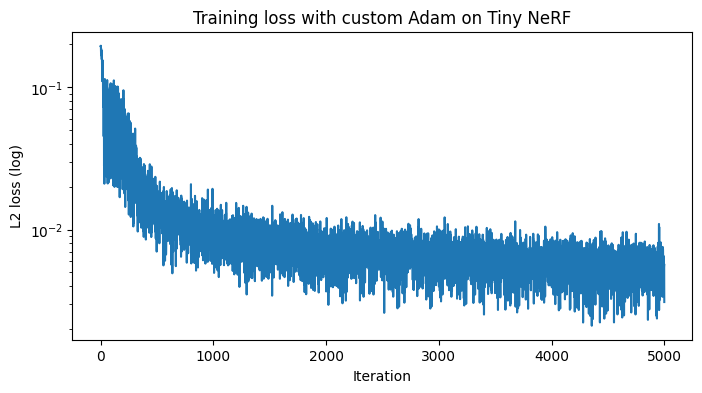

In [12]:
plt.figure(figsize=(8, 4))
plt.semilogy(losses)
plt.xlabel("Iteration"); plt.ylabel("L2 loss (log)")
plt.title("Training loss with custom Adam on Tiny NeRF")
plt.show()

# 10. Render a Novel View

Render the held-out test view (never seen during training). This is the operational definition of "the optimization succeeded": the model can synthesise a view from a pose it was never trained on, demonstrating it learned a coherent 3D representation rather than memorising 2D images.

Rendered novel view (100x100, 64 samples/ray) in 0.03s


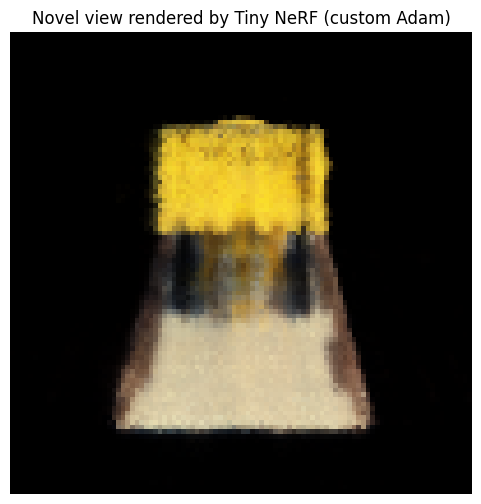

In [13]:
# Render the held-out test view (Cell 2). Time it for the efficiency report.
rays_o, rays_d = get_rays(H, W, focal, test_pose)
rays_o = rays_o.reshape(-1, 3)
rays_d = rays_d.reshape(-1, 3)

t0 = time.time()
with torch.no_grad():
    chunks = []
    for i in range(0, rays_o.shape[0], 4096):
        chunks.append(render_rays(rays_o[i:i+4096], rays_d[i:i+4096], model, encoding))
    pred = torch.cat(chunks, dim=0)
t_render = time.time() - t0

img = pred.reshape(H, W, 3).cpu().numpy()
print(f"Rendered novel view ({H}x{W}, {N_SAMPLES} samples/ray) in {t_render:.2f}s")

plt.figure(figsize=(6, 6))
plt.imshow(np.clip(img, 0, 1))
plt.title("Novel view rendered by Tiny NeRF (custom Adam)")
plt.axis("off")
plt.show()


# 11. Side-By-Side Check

Visual comparison of the rendered novel view against the ground truth held-out image.

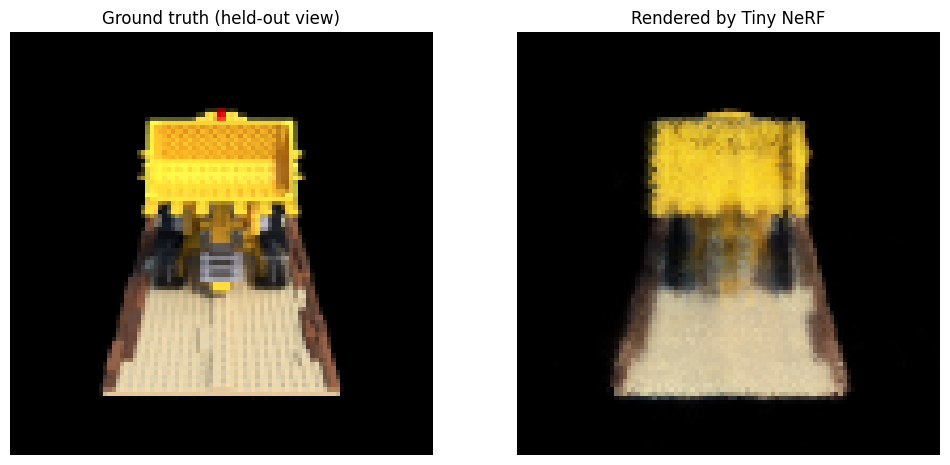

In [14]:
gt = test_image.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gt);                  axes[0].set_title("Ground truth (held-out view)")
axes[1].imshow(np.clip(img, 0, 1));  axes[1].set_title("Rendered by Tiny NeRF")
for a in axes: a.axis("off")
plt.show()

# 12. Quantitative Evaluation (PSNR + SSIM)

PSNR (peak signal-to-noise ratio, in dB) is a pixel-wise metric; higher is better, with anything above 20 dB indicating a coherent reconstruction at this scale. SSIM (structural similarity, in $[0, 1]$) is a perceptual structural metric; closer to 1 is better. The two metrics together give a more honest picture than PSNR alone.

In [15]:
img_c  = np.clip(img, 0, 1).astype(np.float32)
gt_c   = gt.astype(np.float32)

mse  = float(((img_c - gt_c) ** 2).mean())
psnr = -10.0 * np.log10(mse)
ssim = float(ssim_metric(img_c, gt_c, channel_axis=-1, data_range=1.0))

print(f"PSNR: {psnr:.2f} dB")
print(f"SSIM: {ssim:.4f}")


PSNR: 23.83 dB
SSIM: 0.8350


# 13. Render View By Index

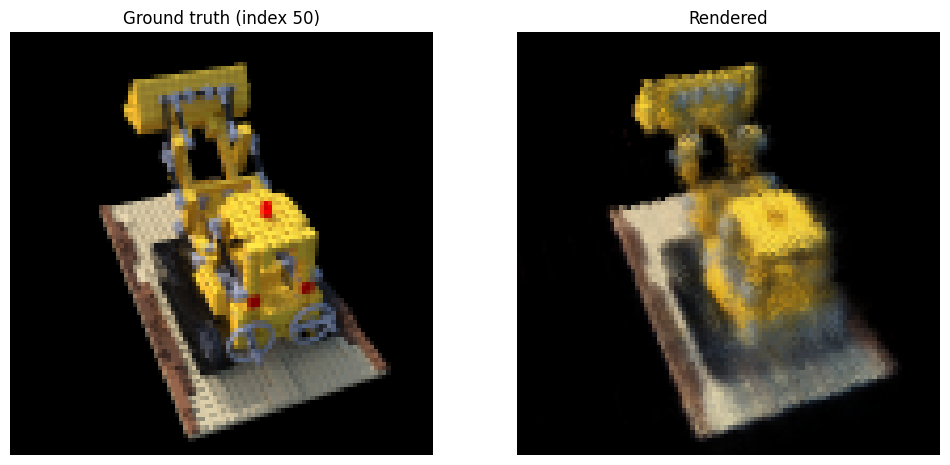

PSNR @ index 50: 22.80 dB


In [16]:
def render_view(pose):
    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o = rays_o.reshape(-1, 3)
    rays_d = rays_d.reshape(-1, 3)
    with torch.no_grad():
        chunks = []
        for i in range(0, rays_o.shape[0], 4096):
            chunks.append(render_rays(rays_o[i:i+4096], rays_d[i:i+4096], model, encoding))
        pred = torch.cat(chunks, dim=0)
    return pred.reshape(H, W, 3).cpu().numpy()

idx = 50   # Any index from 0 to 105
gt = images[idx].cpu().numpy()
rendered = render_view(poses[idx])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(gt);                       axes[0].set_title(f"Ground truth (index {idx})")
axes[1].imshow(np.clip(rendered, 0, 1));  axes[1].set_title("Rendered")
for a in axes: a.axis("off")
plt.show()

mse = ((rendered - gt) ** 2).mean()
print(f"PSNR @ index {idx}: {-10 * np.log10(mse):.2f} dB")

# 14. Orbit Animation

In [17]:
def render_view(pose):
    rays_o, rays_d = get_rays(H, W, focal, pose)
    rays_o = rays_o.reshape(-1, 3)
    rays_d = rays_d.reshape(-1, 3)
    with torch.no_grad():
        chunks = []
        for i in range(0, rays_o.shape[0], 4096):
            chunks.append(render_rays(rays_o[i:i+4096], rays_d[i:i+4096], model, encoding))
        pred = torch.cat(chunks, dim=0)
    return pred.reshape(H, W, 3).cpu().numpy()


def pose_spherical(theta_deg, phi_deg, radius):
    """Camera-to-world matrix at (radius, theta, phi), looking at the origin."""
    theta = np.deg2rad(theta_deg)
    phi   = np.deg2rad(phi_deg)

    c2w = torch.eye(4, device=DEVICE)
    c2w[2, 3] = radius

    R_phi = torch.eye(4, device=DEVICE)
    R_phi[1, 1] =  np.cos(phi);  R_phi[1, 2] = -np.sin(phi)
    R_phi[2, 1] =  np.sin(phi);  R_phi[2, 2] =  np.cos(phi)

    R_theta = torch.eye(4, device=DEVICE)
    R_theta[0, 0] =  np.cos(theta);  R_theta[0, 2] = -np.sin(theta)
    R_theta[2, 0] =  np.sin(theta);  R_theta[2, 2] =  np.cos(theta)

    c2w = R_theta @ R_phi @ c2w

    flip = torch.tensor([
        [-1, 0, 0, 0],
        [ 0, 0, 1, 0],
        [ 0, 1, 0, 0],
        [ 0, 0, 0, 1],
    ], dtype=torch.float32, device=DEVICE)
    return flip @ c2w

In [18]:
import os, imageio
from IPython.display import Video

N_FRAMES  = 60        # frames in the orbit
RADIUS    = 4.0       # camera distance, matches training poses
ELEVATION = -30.0     # degrees; negative looks slightly down

frames = []
t0 = time.time()
for theta in tqdm(np.linspace(0, 360, N_FRAMES + 1)[:-1]):
    pose = pose_spherical(theta, ELEVATION, RADIUS)
    img  = render_view(pose)
    frames.append((np.clip(img, 0, 1) * 255).astype(np.uint8))
t_orbit = time.time() - t0
print(f"Orbit: {N_FRAMES} frames in {t_orbit:.1f}s ({N_FRAMES / t_orbit:.1f} fps)")

OUT_PATH = "../outputs/orbit.mp4"
os.makedirs(os.path.dirname(OUT_PATH), exist_ok=True)
imageio.mimsave(OUT_PATH, frames, fps=24, quality=8)
print(f"Saved {N_FRAMES} frames to {OUT_PATH}")

Video(OUT_PATH, embed=True, width=400)


  0%|          | 0/60 [00:00<?, ?it/s]

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (100, 100) to (112, 112) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Orbit: 60 frames in 28.6s (2.1 fps)
Saved 60 frames to ../outputs/orbit.mp4
